# Credit Card Fraud Detection — Final Model Locking, Persistence and Untouched Test Evaluation

**CodSoft Data Science Internship — Task 5: Credit Card Fraud Detection**
(local folder `Task3_Credit_Card_Fraud_Detection`, my own project numbering)

**Phase 5.** The Phase 4 CANDIDATE FINAL MODEL is locked exactly as selected, trained once on the full
training split, persisted, validated — and only then evaluated, **once**, on the untouched test set. This is
the first and only place in the project where the locked model meets the test data. Nothing is tuned,
re-selected or re-thresholded after that evaluation.

---
## 1. Phase 5 Introduction

| Phase | What it did | Data it used |
|---|---|---|
| Phase 3 | ten baseline configurations, scored once | **previous holdout baseline** (test set) |
| Phase 4 | scaling, imbalance, tuning, threshold, candidate selection | **training-only cross-validation** |
| **Phase 5** | lock → train → persist → validate → **final evaluation** | training split to fit; **test split once, after locking** |

The order of operations in this notebook is the guarantee: the artefact is written and its SHA-256
recorded (section 4) **before** the first test row is read (section 6), and section 6 scores the test set
with the artefact *loaded back from disk*, after re-checking that hash. Section 12 verifies the order by
reading this notebook's own source.

In [1]:
import hashlib
import json
import platform
import subprocess
import sys
import tempfile
import time
import warnings
from pathlib import Path

NOTEBOOK_START = time.perf_counter()

import imblearn
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["grid.alpha"] = 0.3

C_LEGIT, C_FRAUD = "#3b5bdb", "#e8590c"      # class colours, unchanged since Phase 1
C_MODEL = "#9c36b5"                          # the random-forest finalist colour from Phase 4

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "dataset").is_dir() else NOTEBOOK_DIR.parent
NOTEBOOK_PATH = PROJECT_DIR / "notebooks" / "05_final_model_evaluation.ipynb"
VIZ_DIR, RESULTS_DIR, MODELS_DIR = PROJECT_DIR / "visualizations", PROJECT_DIR / "results", PROJECT_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)
if str(PROJECT_DIR / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR / "src"))

import data_preprocessing as dp
import model_training as mt
import predict as predict_api

VERSIONS = {"python": sys.version.split()[0], "pandas": pd.__version__, "numpy": np.__version__,
            "scipy": scipy.__version__, "scikit-learn": sklearn.__version__, "imbalanced-learn": imblearn.__version__,
            "joblib": joblib.__version__, "matplotlib": matplotlib.__version__, "seaborn": sns.__version__}
for k, v in VERSIONS.items():
    print(f"{k:<17} {v}")
print("platform         ", platform.system(), platform.release())

python            3.13.0
pandas            3.0.6
numpy             2.5.3
scipy             1.18.1
scikit-learn      1.9.1
imbalanced-learn  0.14.2
joblib            1.6.0
matplotlib        3.11.2
seaborn           0.13.2
platform          Windows 11


---
## 2. Locked Candidate Configuration

The configuration is read from `results/phase4_candidate.json`, the record Phase 4 wrote, and asserted
field by field against the values Phase 4 reported. Nothing here is chosen: if the record differed, the
notebook would stop.

In [2]:
CANDIDATE_PATH = RESULTS_DIR / "phase4_candidate.json"
CANDIDATE_SHA256 = hashlib.sha256(CANDIDATE_PATH.read_bytes()).hexdigest()
candidate = json.loads(CANDIDATE_PATH.read_text(encoding="utf-8"))

EXPECTED = {
    "model": "random_forest",
    "scaling": "standard",
    "imbalance_strategy": "original",
    "classifier_params": {"min_samples_leaf": 5, "max_depth": None, "max_features": 0.3,
                          "class_weight": None, "n_estimators": 100},
    "candidate_operating_threshold": 0.5,
    "test_set_used": False,
}
for key, value in EXPECTED.items():
    assert candidate[key] == value, f"Phase 4 record differs at {key!r}: {candidate[key]!r} != {value!r}"

LOCKED = {
    "model": candidate["model"],
    "scaling": candidate["scaling"],
    "imbalance_strategy": candidate["imbalance_strategy"],
    "classifier_params": dict(candidate["classifier_params"]),
    "threshold": float(candidate["candidate_operating_threshold"]),
    "decision_rule": "fraud if P(fraud) >= threshold",
}
LOCKED_THRESHOLD = LOCKED["threshold"]

print("=" * 72)
print("LOCKED FINAL CONFIGURATION".center(72))
print("=" * 72)
print(f"source record        : results/phase4_candidate.json  (sha256 {CANDIDATE_SHA256[:16]})")
print(f"model                : Random forest ({mt.FixedOrderRandomForestClassifier.__name__})")
print(f"preprocessing/scaling: {LOCKED['scaling']} - StandardScaler on all 30 features, fitted on training rows")
print(f"imbalance strategy   : {LOCKED['imbalance_strategy']} distribution (no resampling, class_weight=None)")
print(f"hyperparameters      : {LOCKED['classifier_params']}, random_state=42")
print(f"operating threshold  : {LOCKED_THRESHOLD:.2f}   decision rule: {LOCKED['decision_rule']}")
print(f"threshold selected by: {candidate['threshold_rule']}")
print("=" * 72)

                       LOCKED FINAL CONFIGURATION                       
source record        : results/phase4_candidate.json  (sha256 88f9eb1d0b01be68)
model                : Random forest (FixedOrderRandomForestClassifier)
preprocessing/scaling: standard - StandardScaler on all 30 features, fitted on training rows
imbalance strategy   : original distribution (no resampling, class_weight=None)
hyperparameters      : {'min_samples_leaf': 5, 'max_depth': None, 'max_features': 0.3, 'class_weight': None, 'n_estimators': 100}, random_state=42
operating threshold  : 0.50   decision rule: fraud if P(fraud) >= threshold
threshold selected by: Rule 3 - max F1 on out-of-fold training predictions, grid 0.05-0.95, ties to lower


In [3]:
cv = candidate["cv_metrics_at_0_5"]
cv_table = pd.DataFrame({"mean": {m: cv[m]["mean"] for m in cv}, "std": {m: cv[m]["std"] for m in cv}})
cv_table.index = ["PR-AUC", "precision @0.5", "recall @0.5", "F1 @0.5", "ROC-AUC"]
print("PHASE 4 - TRAINING-ONLY 5-FOLD CV of the locked configuration (not test results)")
print(f"folds: StratifiedKFold(5, shuffle=True, random_state=42); fold fingerprint {candidate['cv']['fold_assignment_sha256'][:16]}")
print()
print("out-of-fold at the locked threshold:", {k: (round(v, 6) if isinstance(v, float) else v)
                                               for k, v in candidate["oof_at_candidate_threshold"].items()})
cv_table

PHASE 4 - TRAINING-ONLY 5-FOLD CV of the locked configuration (not test results)
folds: StratifiedKFold(5, shuffle=True, random_state=42); fold fingerprint 30b0865aacf0b2d4

out-of-fold at the locked threshold: {'precision': 0.927445, 'recall': 0.777778, 'f1': 0.846043, 'tp': 294, 'fp': 23, 'fn': 84, 'tn': 226579}


,mean,std
PR-AUC,0.838580,0.044807
precision @0.5,0.926667,0.023880
recall @0.5,0.777719,0.090171
F1 @0.5,0.843867,0.060610
ROC-AUC,0.953749,0.022195


**The decision rule is fixed here, before any test data is read.** Phase 4 selected the threshold with
`P(fraud) >= t` (its threshold table and the out-of-fold figures above use `>=`), so the locked rule is
**fraud if `P(fraud) >= 0.50`**. A random forest's own `predict()` uses a strict `>` (a 50/50 vote goes to
class 0); section 7 reports how many test transactions score exactly 0.50, so the effect of this
distinction is visible rather than assumed.

---
## 3. Final Training

The Phase 2 split is reproduced and verified; the test split is fingerprinted and **set aside untouched**.
The locked pipeline is then fitted once on all 226,980 training rows — scaler and forest both.

In [4]:
# TEST-LOCK CELL - fingerprints and sets aside the test split. It is not read again until section 6.
SHA256_INITIAL = dp.sha256_of_file(dp.default_dataset_path())
assert SHA256_INITIAL == dp.RAW_DATASET_SHA256, "raw dataset checksum mismatch - STOP"

df = dp.load_data()
split = dp.split_data(df)
X_train, y_train = split.X_train, split.y_train


def frame_fingerprint(X, y):
    digest = hashlib.sha256()
    digest.update(np.ascontiguousarray(X.index.to_numpy()).tobytes())
    digest.update(np.ascontiguousarray(X.to_numpy()).tobytes())
    digest.update(np.ascontiguousarray(y.to_numpy()).tobytes())
    return digest.hexdigest()


PHASE3_TEST_FINGERPRINT = "50a7a7a9ab2a1efdb5ed371e35593bd19f04a3276b08ce31ef3a51017187f27e"
TEST_FINGERPRINT_LOCK = frame_fingerprint(split.X_test, split.y_test)
TEST_INDEX = split.X_test.index.copy()
_SEALED_TEST = (split.X_test, split.y_test)       # opened only in section 6
del split, df

lock_checks = {
    "raw checksum = Phase 1 record": SHA256_INITIAL == dp.RAW_DATASET_SHA256,
    "train rows 226,980 (226,602 / 378)": len(X_train) == 226_980 and y_train.value_counts().to_dict() == {0: 226_602, 1: 378},
    "test rows 56,746 (56,651 / 95)": len(_SEALED_TEST[0]) == 56_746 and _SEALED_TEST[1].value_counts().to_dict() == {0: 56_651, 1: 95},
    "test fingerprint = Phase 3/4 record": TEST_FINGERPRINT_LOCK == PHASE3_TEST_FINGERPRINT,
    "train/test rows disjoint": len(X_train.index.intersection(TEST_INDEX)) == 0,
}
for name, ok in lock_checks.items():
    print(f"{name:<38}: {'OK' if ok else 'FAILED'}")
assert all(lock_checks.values())

raw checksum = Phase 1 record         : OK
train rows 226,980 (226,602 / 378)    : OK
test rows 56,746 (56,651 / 95)        : OK
test fingerprint = Phase 3/4 record   : OK
train/test rows disjoint              : OK


In [5]:
final_pipeline = mt.build_pipeline(LOCKED["model"], LOCKED["imbalance_strategy"], scaling=LOCKED["scaling"],
                                   classifier_params=LOCKED["classifier_params"])
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    t0 = time.perf_counter()
    final_pipeline.fit(X_train, y_train)          # TRAINING ROWS ONLY
    FIT_SECONDS = time.perf_counter() - t0

clf = final_pipeline.named_steps["classifier"]
scaler = final_pipeline.named_steps["preprocess"].named_transformers_["scale_all"]
fit_checks = {
    "pipeline steps": " -> ".join(final_pipeline.named_steps),
    "no resampling step": "resample" not in final_pipeline.named_steps,
    "scaler fitted on training rows only (n_samples_seen_)": int(scaler.n_samples_seen_) == len(X_train),
    "classifier class": type(clf).__name__,
    "trees grown": len(clf.estimators_),
    "classifier params match the lock": all(clf.get_params()[k] == v for k, v in LOCKED["classifier_params"].items()),
    "random_state": clf.random_state,
    "warnings raised during fit": len(caught),
}
print(f"fitted on {len(X_train):,} training rows in {FIT_SECONDS:.1f} s")
for k, v in fit_checks.items():
    print(f"  {k:<55}: {v}")
assert fit_checks["no resampling step"] and fit_checks["scaler fitted on training rows only (n_samples_seen_)"]
assert fit_checks["classifier params match the lock"] and fit_checks["trees grown"] == 100

fitted on 226,980 training rows in 147.5 s
  pipeline steps                                         : preprocess -> classifier
  no resampling step                                     : True
  scaler fitted on training rows only (n_samples_seen_)  : True
  classifier class                                       : FixedOrderRandomForestClassifier
  trees grown                                            : 100
  classifier params match the lock                       : True
  random_state                                           : 42
  warnings raised during fit                             : 0


In [6]:
train_proba = final_pipeline.predict_proba(X_train)[:, 1]
train_pred = (train_proba >= LOCKED_THRESHOLD).astype(int)
print("TRAIN (in-sample, all 226,980 training rows) - recorded for context, never used for any decision:")
print(f"  PR-AUC {average_precision_score(y_train, train_proba):.6f} | precision {precision_score(y_train, train_pred):.6f} | "
      f"recall {recall_score(y_train, train_pred):.6f} | F1 {f1_score(y_train, train_pred):.6f}")
print("  (in-sample scores of a forest are optimistic by construction - Phase 4 measured the gap under CV)")

TRAIN (in-sample, all 226,980 training rows) - recorded for context, never used for any decision:
  PR-AUC 0.974120 | precision 0.972222 | recall 0.833333 | F1 0.897436
  (in-sample scores of a forest are optimistic by construction - Phase 4 measured the gap under CV)


---
## 4. Model Persistence

The artefact is a dictionary holding the fitted pipeline **and** the locked threshold, feature order and
provenance, so the prediction rule travels with the model and cannot drift. No timestamp is stored, so an
identical fit produces an identical file.

In [7]:
# ARTIFACT-LOCK CELL - the model is frozen here, before any test row is read.
MODEL_PATH = MODELS_DIR / "final_credit_card_fraud_pipeline.joblib"
artifact = {
    "pipeline": final_pipeline,
    "threshold": LOCKED_THRESHOLD,
    "decision_rule": LOCKED["decision_rule"],
    "feature_columns": list(predict_api.FEATURE_COLUMNS),
    "metadata": {
        "project": "CodSoft Task 5 - Credit Card Fraud Detection (local Task3_Credit_Card_Fraud_Detection)",
        "model": "random forest (FixedOrderRandomForestClassifier, src/model_training.py)",
        "scaling": LOCKED["scaling"],
        "imbalance_strategy": LOCKED["imbalance_strategy"],
        "classifier_params": LOCKED["classifier_params"],
        "random_state": 42,
        "threshold_rule": candidate["threshold_rule"],
        "selected_by": candidate["selected_by"],
        "phase4_candidate_sha256": CANDIDATE_SHA256,
        "cv_metrics_at_0_5": candidate["cv_metrics_at_0_5"],
        "training_rows": int(len(X_train)),
        "training_class_counts": {int(k): int(v) for k, v in y_train.value_counts().sort_index().items()},
        "raw_dataset_sha256": SHA256_INITIAL,
        "versions": VERSIONS,
    },
}
joblib.dump(artifact, MODEL_PATH, compress=3)
ARTIFACT_SHA256_AT_LOCK = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
ARTIFACT_BYTES = MODEL_PATH.stat().st_size
print(f"artefact : {MODEL_PATH.relative_to(PROJECT_DIR).as_posix()}")
print(f"size     : {ARTIFACT_BYTES:,} bytes ({ARTIFACT_BYTES / 1024**2:.2f} MiB)")
print(f"sha256   : {ARTIFACT_SHA256_AT_LOCK}")
print(f"threshold: {LOCKED_THRESHOLD:.2f} (stored inside the artefact)")

artefact : models/final_credit_card_fraud_pipeline.joblib
size     : 501,175 bytes (0.48 MiB)
sha256   : fb538208042767a69c8a897e0824784cd513bfcadfa6cb63b10435471c8274f9
threshold: 0.50 (stored inside the artefact)


In [8]:
# A human-readable companion. predict.py reads the threshold from the artefact itself, not from here.
model_card = {
    "artifact": MODEL_PATH.relative_to(PROJECT_DIR).as_posix(),
    "artifact_sha256": ARTIFACT_SHA256_AT_LOCK,
    "artifact_bytes": ARTIFACT_BYTES,
    "threshold": LOCKED_THRESHOLD,
    "decision_rule": LOCKED["decision_rule"],
    "feature_columns": list(predict_api.FEATURE_COLUMNS),
    **{k: v for k, v in artifact["metadata"].items() if k != "versions"},
    "versions": VERSIONS,
}
(MODELS_DIR / "final_model_metadata.json").write_text(json.dumps(model_card, indent=2) + "\n", encoding="utf-8")
print("wrote models/final_model_metadata.json")

wrote models/final_model_metadata.json


---
## 5. Artifact Validation

Still before any test row is read: the artefact is loaded back through `src/predict.py` (the same code path
the dashboard uses), compared with the in-memory model, loaded again in a **separate Python process**, and
put through valid and invalid inputs. The comparisons use training rows.

In [9]:
predict_api._load_cached.cache_clear()
loaded = predict_api.load_artifact(MODEL_PATH)
probe = X_train.iloc[:2000]
in_memory = final_pipeline.predict_proba(probe)[:, 1]
from_disk = loaded["pipeline"].predict_proba(probe)[:, 1]
print("artefact loads                        :", isinstance(loaded, dict))
print("threshold from artefact               :", predict_api.model_threshold(MODEL_PATH))
print("feature order matches                 :", tuple(loaded["feature_columns"]) == predict_api.FEATURE_COLUMNS)
print("2,000 training rows: disk == memory   :", np.array_equal(in_memory, from_disk),
      f"(max |diff| {np.max(np.abs(in_memory - from_disk)):.1e})")

artefact loads                        : True
threshold from artefact               : 0.5
feature order matches                 : True
2,000 training rows: disk == memory   : True (max |diff| 0.0e+00)


In [10]:
FRESH_PROCESS_SCRIPT = '''
import sys, json, numpy as np, pandas as pd
sys.path.insert(0, sys.argv[1])
import predict
frame = pd.read_parquet(sys.argv[2])
out = predict.load_artifact(sys.argv[3])["pipeline"].predict_proba(frame)[:, 1]
np.save(sys.argv[4], out)
print(json.dumps({"threshold": predict.model_threshold(sys.argv[3]), "rows": len(frame)}))
'''


def score_in_fresh_process(frame: pd.DataFrame) -> tuple[np.ndarray, dict]:
    """Load the artefact in a brand-new interpreter and score `frame` there."""
    with tempfile.TemporaryDirectory() as tmp:
        src_path, out_path = Path(tmp) / "rows.parquet", Path(tmp) / "proba.npy"
        frame.to_parquet(src_path)
        done = subprocess.run([sys.executable, "-c", FRESH_PROCESS_SCRIPT, str(PROJECT_DIR / "src"), str(src_path),
                               str(MODEL_PATH), str(out_path)], capture_output=True, text=True, timeout=600)
        if done.returncode != 0:
            raise RuntimeError(done.stderr)
        return np.load(out_path), json.loads(done.stdout.strip().splitlines()[-1])


PERSISTENCE_TOLERANCE = 1e-12        # documented tolerance; bit-identical results are expected
fresh_train, fresh_info = score_in_fresh_process(probe)
print("fresh process reported           :", fresh_info)
print("fresh process == in-memory       :", np.array_equal(fresh_train, in_memory),
      f"(max |diff| {np.max(np.abs(fresh_train - in_memory)):.1e}, tolerance {PERSISTENCE_TOLERANCE:g})")
assert np.max(np.abs(fresh_train - in_memory)) <= PERSISTENCE_TOLERANCE

fresh process reported           : {'threshold': 0.5, 'rows': 2000}
fresh process == in-memory       : True (max |diff| 0.0e+00, tolerance 1e-12)


In [11]:
legit_row = X_train[y_train == 0].iloc[0]
fraud_row = X_train[y_train == 1].iloc[0]
smoke = []


def expect_ok(name, transaction):
    result = predict_api.predict_transaction(transaction, MODEL_PATH)
    ok = set(result) == {"fraud_probability", "predicted_class", "label", "threshold"} and 0 <= result["fraud_probability"] <= 1
    smoke.append((name, ok, f"P(fraud)={result['fraud_probability']:.4f} -> {result['label']}"))


def expect_error(name, transaction):
    try:
        predict_api.predict_transaction(transaction, MODEL_PATH)
        smoke.append((name, False, "accepted - should have been rejected"))
    except predict_api.InvalidTransactionError as exc:
        smoke.append((name, True, f"InvalidTransactionError: {exc}"))


valid = legit_row.to_dict()
expect_ok("1. valid legitimate transaction (a training row)", legit_row.to_dict())
expect_ok("2. valid fraud transaction (a training row)", fraud_row.to_dict())
expect_error("3. missing feature", {k: v for k, v in valid.items() if k != "V14"})
expect_error("4. NaN value", {**valid, "V4": float("nan")})
expect_error("5. infinite value", {**valid, "Amount": float("inf")})
expect_error("6. wrong feature count", list(valid.values())[:29])
expect_error("7a. malformed value", {**valid, "V2": "12,5x"})
expect_error("7b. malformed input type", "not a transaction")
expect_error("7c. target column supplied", {**valid, "Class": 1})
smoke_table = pd.DataFrame(smoke, columns=["smoke test", "passed", "outcome"])
assert smoke_table["passed"].all()
print(f"prediction smoke tests passed: {int(smoke_table['passed'].sum())} / {len(smoke_table)}")
smoke_table

prediction smoke tests passed: 9 / 9


,smoke test,passed,outcome
0,1. valid legitimate transaction (a training row),True,P(fraud)=0.0000 -> LEGITIMATE
1,2. valid fraud transaction (a training row),True,P(fraud)=0.9977 -> FRAUD
2,3. missing feature,True,InvalidTransactionError: Missing 1 feature(s):...
3,4. NaN value,True,InvalidTransactionError: 'V4' is NaN; a real n...
4,5. infinite value,True,InvalidTransactionError: 'Amount' is infinite;...
5,6. wrong feature count,True,InvalidTransactionError: Expected 30 values (T...
6,7a. malformed value,True,InvalidTransactionError: 'V2' must be a number...
7,7b. malformed input type,True,InvalidTransactionError: A transaction must be...
8,7c. target column supplied,True,InvalidTransactionError: Unexpected feature(s)...


---
## 6. Untouched Test Evaluation

**The model is locked.** Before the test set is opened, the artefact on disk is re-hashed and must equal the
hash recorded at the lock. The test set is then scored **once**, with the artefact loaded back from disk,
at the locked threshold. Nothing below this point changes the model, its configuration or its threshold.

In [12]:
# FINAL-EVALUATION CELL - the first and only scoring of the test set.
assert hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest() == ARTIFACT_SHA256_AT_LOCK, "artefact changed - STOP"
predict_api._load_cached.cache_clear()
locked_artifact = predict_api.load_artifact(MODEL_PATH)
assert locked_artifact["threshold"] == LOCKED_THRESHOLD

X_test, y_test = _SEALED_TEST
test_proba = locked_artifact["pipeline"].predict_proba(X_test)[:, 1]
test_pred = (test_proba >= LOCKED_THRESHOLD).astype(int)
y_true = y_test.to_numpy()
TEST_SCORED_AT = time.perf_counter() - NOTEBOOK_START
print(f"test rows scored: {len(test_proba):,} | fraud in test: {int(y_true.sum())} | threshold {LOCKED_THRESHOLD:.2f}")

test rows scored: 56,746 | fraud in test: 95 | threshold 0.50


---
## 7. Final Metrics — FINAL TEST RESULTS (Phase 5)

Fraud (`Class = 1`) is the positive class throughout. Precision, recall, F1, accuracy and the confusion
matrix use the locked decision rule; PR-AUC and ROC-AUC use the predicted probabilities.

In [13]:
tn, fp, fn, tp = confusion_matrix(y_true, test_pred, labels=[0, 1]).ravel()
FINAL = {
    "accuracy": accuracy_score(y_true, test_pred),
    "precision": precision_score(y_true, test_pred, pos_label=1, zero_division=0),
    "recall": recall_score(y_true, test_pred, pos_label=1, zero_division=0),
    "f1": f1_score(y_true, test_pred, pos_label=1, zero_division=0),
    "pr_auc": average_precision_score(y_true, test_proba, pos_label=1),
    "roc_auc": roc_auc_score(y_true, test_proba),
    "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    "false_positive_rate": fp / (fp + tn),
    "false_negative_rate": fn / (fn + tp),
    "specificity": tn / (tn + fp),
    "support_legitimate": int((y_true == 0).sum()),
    "support_fraud": int((y_true == 1).sum()),
}
rows = [("Accuracy", FINAL["accuracy"]), ("Precision (fraud)", FINAL["precision"]), ("Recall (fraud)", FINAL["recall"]),
        ("F1 (fraud)", FINAL["f1"]), ("PR-AUC (average precision)", FINAL["pr_auc"]), ("ROC-AUC", FINAL["roc_auc"]),
        ("Specificity (legitimate recall)", FINAL["specificity"]), ("False positive rate", FINAL["false_positive_rate"]),
        ("False negative rate", FINAL["false_negative_rate"])]
final_table = pd.DataFrame(rows, columns=["Metric", "FINAL TEST RESULT"]).set_index("Metric")
print(f"FINAL TEST RESULTS - locked model, threshold {LOCKED_THRESHOLD:.2f}, {len(y_true):,} test transactions")
print(f"TN {tn:,} | FP {fp:,} | FN {fn:,} | TP {tp:,} | support: legitimate {FINAL['support_legitimate']:,}, fraud {FINAL['support_fraud']}")
final_table

FINAL TEST RESULTS - locked model, threshold 0.50, 56,746 test transactions
TN 56,647 | FP 4 | FN 26 | TP 69 | support: legitimate 56,651, fraud 95


,FINAL TEST RESULT
Metric,
Accuracy,0.999471
Precision (fraud),0.945205
Recall (fraud),0.726316
F1 (fraud),0.821429
PR-AUC (average precision),0.793217
ROC-AUC,0.936863
Specificity (legitimate recall),0.999929
False positive rate,0.000071
False negative rate,0.273684


In [14]:
at_exact = int(np.sum(test_proba == LOCKED_THRESHOLD))
strict_pred = (test_proba > LOCKED_THRESHOLD).astype(int)
print(f"test transactions scoring exactly {LOCKED_THRESHOLD:.2f}: {at_exact}")
print(f"predictions that would change under a strict '>' rule: {int((strict_pred != test_pred).sum())}")
print(f"  of which fraud: {int(((strict_pred != test_pred) & (y_true == 1)).sum())}")

test transactions scoring exactly 0.50: 0
predictions that would change under a strict '>' rule: 0
  of which fraud: 0


### 7.1 How precise are these numbers? — a descriptive bootstrap

The test set contains 95 frauds, so every fraud-class metric carries real sampling uncertainty. The
intervals below resample the 56,746 test rows with replacement (2,000 resamples, `random_state=42`) and
report the 2.5th–97.5th percentiles. They describe the uncertainty **of this evaluation**; they are not
used for any decision and do not change the model.

In [15]:
rng = np.random.default_rng(42)
n = len(y_true)
boot = {"precision": [], "recall": [], "f1": [], "pr_auc": [], "roc_auc": []}
for _ in range(2000):
    idx = rng.integers(0, n, n)
    yt, pp, pr = y_true[idx], test_pred[idx], test_proba[idx]
    if yt.sum() == 0:
        continue
    boot["precision"].append(precision_score(yt, pp, zero_division=0))
    boot["recall"].append(recall_score(yt, pp, zero_division=0))
    boot["f1"].append(f1_score(yt, pp, zero_division=0))
    boot["pr_auc"].append(average_precision_score(yt, pr))
    boot["roc_auc"].append(roc_auc_score(yt, pr))
BOOTSTRAP = {m: {"low": float(np.percentile(v, 2.5)), "high": float(np.percentile(v, 97.5)), "resamples": len(v)}
             for m, v in boot.items()}
pd.DataFrame({m: {"point estimate": FINAL[m], "2.5%": BOOTSTRAP[m]["low"], "97.5%": BOOTSTRAP[m]["high"]}
              for m in boot}).T

,point estimate,2.5%,97.5%
precision,0.945205,0.886067,0.987809
recall,0.726316,0.633323,0.812500
f1,0.821429,0.753243,0.879121
pr_auc,0.793217,0.712547,0.867677
roc_auc,0.936863,0.901324,0.968248


### 7.2 Phase 3 vs Phase 4 vs Phase 5 — three different evaluations

| Label | Meaning |
|---|---|
| **Phase 3 — previous holdout baseline** | untuned baseline configurations, scored once on this same test set; copied verbatim |
| **Phase 4 — training-only CV** | mean of five validation folds from the training split; the basis of selection |
| **Phase 5 — final locked-model test evaluation** | this notebook; the only unbiased estimate for the locked model |

In [16]:
comparison = pd.DataFrame({
    "Phase 3 holdout: RF original (default)": {"pr_auc": 0.787618, "precision": 0.971831, "recall": 0.726316, "f1": 0.831325, "roc_auc": 0.923949},
    "Phase 3 holdout: RF + SMOTE (highest Phase 3 PR-AUC)": {"pr_auc": 0.811967, "precision": 0.912500, "recall": 0.768421, "f1": 0.834286, "roc_auc": 0.969390},
    "Phase 4 CV: locked configuration (mean of 5 folds)": {m: cv[m]["mean"] for m in ("pr_auc", "precision", "recall", "f1", "roc_auc")},
    "Phase 5 FINAL TEST: locked model": {m: FINAL[m] for m in ("pr_auc", "precision", "recall", "f1", "roc_auc")},
}).T[["pr_auc", "precision", "recall", "f1", "roc_auc"]]
comparison

,pr_auc,precision,recall,f1,roc_auc
Phase 3 holdout: RF original (default),0.787618,0.971831,0.726316,0.831325,0.923949
Phase 3 holdout: RF + SMOTE (highest Phase 3 PR-AUC),0.811967,0.912500,0.768421,0.834286,0.969390
Phase 4 CV: locked configuration (mean of 5 folds),0.838580,0.926667,0.777719,0.843867,0.953749
Phase 5 FINAL TEST: locked model,0.793217,0.945205,0.726316,0.821429,0.936863


**Reading the final result.** On the 56,746 untouched test transactions the locked model catches **69 of the 95 frauds (recall 0.726316)** and raises **4 false alarms (precision 0.945205)**; F1 is **0.821429** and PR-AUC **0.793217**. Accuracy is **0.999471** — reported, but uninformative on its own: a model that flags nothing scores 0.998326 here.

**Against its own cross-validation estimate**, the test result is lower on PR-AUC (**0.793217** vs **0.838580**), recall (**0.726316** vs **0.777719**) and F1, and higher on precision (**0.945205** vs **0.926667**). That direction was anticipated in Phase 4: the CV score belongs to the configuration chosen *on those folds*, so it is optimistic, and this test split already scored lower than CV for nine of the ten Phase 3 configurations. The test PR-AUC sits inside the range the candidate showed across its five CV folds (**0.768–0.880**), and the CV mean lies inside the test result's bootstrap interval (**[0.713, 0.868]**). The gap is consistent with sampling variation plus selection optimism; it is not evidence that the model broke.

**How precise is 0.726 recall?** Not very: its bootstrap interval is **[0.633, 0.813]**, because it rests on 95 frauds. One fraud more or less moves recall by about one point.

**Relative to Phase 3.** The locked model's recall equals that of three of Phase 3's untuned forests (69 of 95 caught), with the same number of false alarms (4) as the class-weighted one (per-row Phase 3 predictions were not stored, so whether they are the same transactions is unknown), and its PR-AUC (0.793217) is similar to theirs (0.787618–0.802386). Tuning in Phase 4 reduced overfitting substantially, but did not buy a large test-set gain — which is what Phase 4's CV results predicted (differences between the forests were inside one standard error). These are separate evaluations, not a contest: Phase 3's numbers were never used to choose this model.

**The ≥ vs > question is moot here:** no test transaction scored exactly 0.50, so the locked rule and a strict rule give identical predictions.

---
## 8. Confusion Matrix

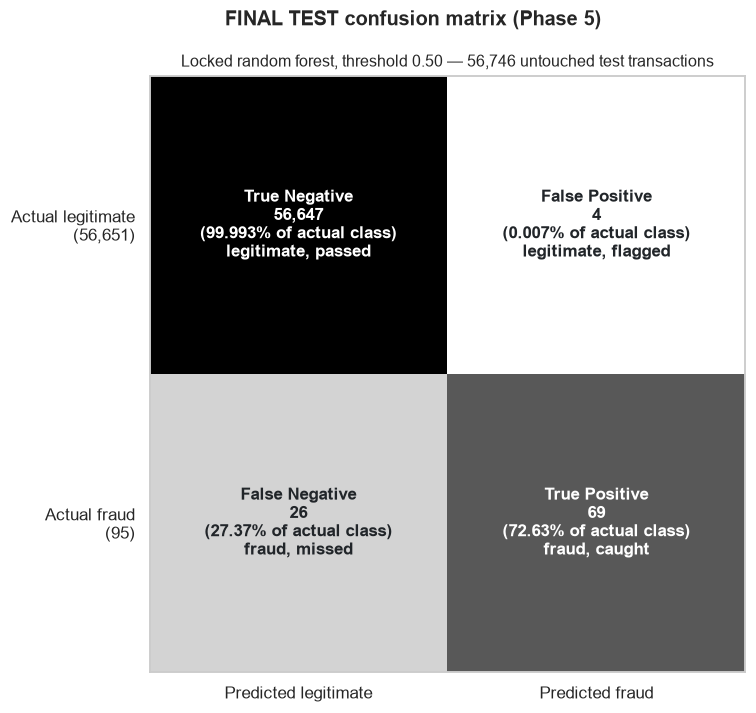

In [17]:
def share(x):
    pct = x * 100
    return f"{pct:.3f}%" if (0 < pct < 0.1 or 99.9 < pct < 100) else f"{pct:.2f}%"

counts = np.array([[tn, fp], [fn, tp]])
row_share = counts / counts.sum(axis=1, keepdims=True)
names = [["True Negative", "False Positive"], ["False Negative", "True Positive"]]
meaning = [["legitimate, passed", "legitimate, flagged"], ["fraud, missed", "fraud, caught"]]
fig, ax = plt.subplots(figsize=(8.2, 6.6))
ax.imshow(row_share, cmap="Greys", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ink = "white" if row_share[i, j] > 0.55 else "#212529"
        ax.text(j, i, f"{names[i][j]}\n{counts[i, j]:,}\n({share(row_share[i, j])} of actual class)\n{meaning[i][j]}",
                ha="center", va="center", fontsize=11, color=ink, fontweight="bold")
ax.set_xticks([0, 1], ["Predicted legitimate", "Predicted fraud"], fontsize=11)
ax.set_yticks([0, 1], [f"Actual legitimate\n({tn + fp:,})", f"Actual fraud\n({fn + tp})"], fontsize=11)
ax.grid(False)
ax.set_title(f"Locked random forest, threshold {LOCKED_THRESHOLD:.2f} — {len(y_true):,} untouched test transactions",
             fontsize=10.5, fontweight="normal")
fig.suptitle("FINAL TEST confusion matrix (Phase 5)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "25_final_confusion_matrix.png")
plt.show()

**Operational meaning.**

* **4 false positives** — legitimate transactions flagged as fraud. In practice each would be a blocked or challenged card payment and a review for an analyst: 4 of 56,651 legitimate transactions (**0.007%**).
* **26 false negatives** — frauds let through undetected, **27.37%** of the fraud in the test set. Each is a fraudulent payment that would complete.

Which error matters more is not something the data can settle. It depends on the cost of a missed fraud versus the cost (and customer impact) of a false alarm, and on how alerts are handled downstream — none of which is in this dataset. At this threshold the model is tuned toward very few false alarms; section 11 of Phase 4 showed that lowering the threshold would catch more fraud at the price of more alerts. That trade-off is a business decision, and the threshold was deliberately not moved after seeing these results.

---
## 9. Precision-Recall Curve

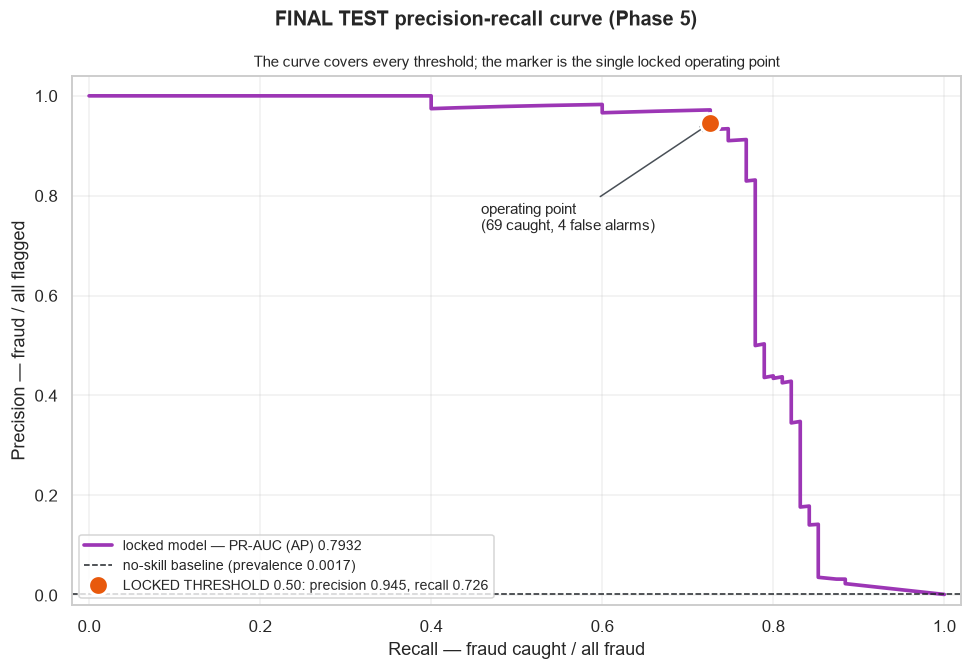

In [18]:
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_true, test_proba, pos_label=1)
prevalence = float(y_true.mean())
fig, ax = plt.subplots(figsize=(9, 6.2))
ax.plot(rec_curve, prec_curve, color=C_MODEL, linewidth=2.4, label=f"locked model — PR-AUC (AP) {FINAL['pr_auc']:.4f}")
ax.axhline(prevalence, color="#212529", ls="--", linewidth=1, label=f"no-skill baseline (prevalence {prevalence:.4f})")
ax.plot(FINAL["recall"], FINAL["precision"], marker="o", markersize=13, color=C_FRAUD, markeredgecolor="white",
        markeredgewidth=2, linestyle="none", zorder=5,
        label=f"LOCKED THRESHOLD {LOCKED_THRESHOLD:.2f}: precision {FINAL['precision']:.3f}, recall {FINAL['recall']:.3f}")
ax.annotate(f"operating point\n({tp} caught, {fp} false alarms)", xy=(FINAL["recall"], FINAL["precision"]),
            xytext=(-150, -70), textcoords="offset points", fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color="#495057"))
ax.set_xlabel("Recall — fraud caught / all fraud")
ax.set_ylabel("Precision — fraud / all flagged")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.04)
ax.legend(loc="lower left", fontsize=9, frameon=True)
ax.set_title("The curve covers every threshold; the marker is the single locked operating point", fontsize=10, fontweight="normal")
fig.suptitle("FINAL TEST precision-recall curve (Phase 5)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "26_final_precision_recall_curve.png")
plt.show()

---
## 10. ROC Curve

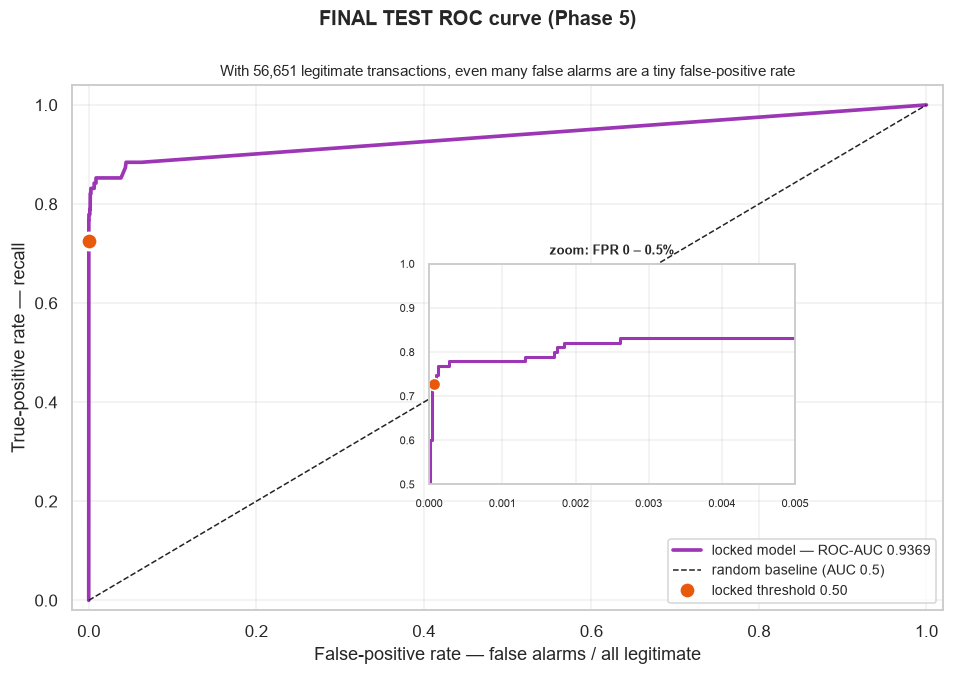

In [19]:
fpr_curve, tpr_curve, _ = roc_curve(y_true, test_proba, pos_label=1)
fig, ax = plt.subplots(figsize=(9, 6.2))
ax.plot(fpr_curve, tpr_curve, color=C_MODEL, linewidth=2.4, label=f"locked model — ROC-AUC {FINAL['roc_auc']:.4f}")
ax.plot([0, 1], [0, 1], color="#212529", ls="--", linewidth=1, label="random baseline (AUC 0.5)")
ax.plot(FINAL["false_positive_rate"], FINAL["recall"], marker="o", markersize=11, color=C_FRAUD, markeredgecolor="white",
        markeredgewidth=2, linestyle="none", zorder=5, label=f"locked threshold {LOCKED_THRESHOLD:.2f}")
ax.set_xlabel("False-positive rate — false alarms / all legitimate")
ax.set_ylabel("True-positive rate — recall")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.04)
ax.legend(loc="lower right", fontsize=9, frameon=True)
inset = inset_axes(ax, width="42%", height="42%", loc="center", bbox_to_anchor=(0.12, -0.05, 1, 1), bbox_transform=ax.transAxes)
inset.plot(fpr_curve, tpr_curve, color=C_MODEL, linewidth=2)
inset.plot(FINAL["false_positive_rate"], FINAL["recall"], marker="o", markersize=8, color=C_FRAUD, markeredgecolor="white")
inset.set_xlim(0, 0.005)
inset.set_ylim(0.5, 1.0)
inset.set_title("zoom: FPR 0 – 0.5%", fontsize=8.5)
inset.tick_params(labelsize=7.5)
fig.suptitle("FINAL TEST ROC curve (Phase 5)", fontsize=13, fontweight="bold")
ax.set_title("With 56,651 legitimate transactions, even many false alarms are a tiny false-positive rate",
             fontsize=10, fontweight="normal")
fig.subplots_adjust(left=0.09, right=0.97, bottom=0.1, top=0.87)   # inset axes are incompatible with tight_layout
fig.savefig(VIZ_DIR / "27_final_roc_curve.png")
plt.show()

**Precision-recall (the informative view).** The curve holds precision near 1.0 up to recall ≈ 0.40 and above 0.9 until just past the operating point, then falls steeply beyond recall ≈ 0.78 — the same cliff Phase 4 found out-of-fold. The locked threshold sits just before that cliff. PR-AUC (**0.793217**) is about **474×** the no-skill level of 0.0017.

**ROC (recorded, secondary).** ROC-AUC is **0.936863**. Note the long straight segment from a false-positive rate of about 0.06 to 1.0: those are frauds the forest scores at (or near) zero, tied with most legitimate transactions, so ROC cannot rank them. The operating point sits at a false-positive rate of **0.000071** — the zoom is needed to see it at all. That is why ROC is a poor guide here: with 56,651 legitimate transactions, even hundreds of false alarms would barely move the x-axis, while they would dominate an analyst's queue. PR-AUC, whose precision axis counts every false alarm against the flagged set, remains the primary metric.

---
## 11. Error Analysis

Descriptive only. A pattern in the errors describes *which* transactions the model gets wrong; it is not a
claim about why, and nothing here is used to change the model.

In [20]:
outcome = np.select([(y_true == 1) & (test_pred == 1), (y_true == 1) & (test_pred == 0),
                     (y_true == 0) & (test_pred == 1)], ["TP (fraud caught)", "FN (fraud missed)", "FP (false alarm)"],
                    default="TN (legitimate passed)")
analysis = X_test[["Time", "Amount", "V14", "V17", "V12", "V10"]].copy()
analysis["hours"] = analysis["Time"] / 3600
analysis["P(fraud)"] = test_proba
analysis["outcome"] = outcome
summary = analysis.groupby("outcome").agg(
    count=("Amount", "size"),
    amount_mean=("Amount", "mean"), amount_median=("Amount", "median"), amount_max=("Amount", "max"),
    hours_median=("hours", "median"), prob_median=("P(fraud)", "median"), prob_min=("P(fraud)", "min"),
    prob_max=("P(fraud)", "max"),
    V14_median=("V14", "median"), V17_median=("V17", "median"), V12_median=("V12", "median"), V10_median=("V10", "median"),
).loc[["TP (fraud caught)", "FN (fraud missed)", "FP (false alarm)", "TN (legitimate passed)"]]
summary

,count,amount_mean,amount_median,amount_max,hours_median,prob_median,prob_min,prob_max,V14_median,V17_median,V12_median,V10_median
outcome,,,,,,,,,,,,
TP (fraud caught),69,151.491014,33.590000,"1,809.680000",21.105000,0.925535,0.533769,1.000000,-7.279869,-5.701174,-6.163537,-5.208335
FN (fraud missed),26,165.901154,2.990000,"1,096.990000",18.355000,0.002000,0.000000,0.474731,-1.019143,0.918977,-0.415009,-0.326820
FP (false alarm),4,"6,680.285000",510.495000,"25,691.160000",20.746250,0.656800,0.511039,0.917384,-4.947829,-6.705452,-5.563956,-4.526379
TN (legitimate passed),56647,88.237766,21.600000,"11,898.090000",23.465556,0.000000,0.000000,0.483354,0.057246,-0.066242,0.144642,-0.090449


In [21]:
print("Missed frauds (FN), sorted by P(fraud):")
print(analysis[analysis["outcome"] == "FN (fraud missed)"].sort_values("P(fraud)", ascending=False)
      [["hours", "Amount", "P(fraud)", "V14", "V17", "V12", "V10"]].round(4).to_string())
print()
print("False alarms (FP), sorted by P(fraud):")
print(analysis[analysis["outcome"] == "FP (false alarm)"].sort_values("P(fraud)", ascending=False)
      [["hours", "Amount", "P(fraud)", "V14", "V17", "V12", "V10"]].round(4).to_string())

Missed frauds (FN), sorted by P(fraud):
           hours       Amount  P(fraud)       V14       V17       V12       V10
18409   8.203100     0.680000  0.474700 -7.311600  6.509300 -2.591900 -2.335900
149032 25.431700   261.220000  0.471600 -4.220400 -2.372400 -5.034000 -3.717500
4886    1.239400   239.930000  0.405100 -1.470100 -4.781800 -6.560100 -1.525400
87035  17.123900    19.040000  0.399800 -3.431700 -3.901500 -2.317000  0.169600
228883 40.562800     2.220000  0.157000 -4.942600  3.702100 -0.741100 -0.628500
10442   4.774200     3.790000  0.038500 -0.330300  2.299000 -2.547600 -0.592500
93461  17.940300     0.000000  0.032100 -1.880300  1.522700 -0.276300 -0.194100
14285   7.062800     3.760000  0.031300 -2.238600  1.776500 -0.491200 -0.369900
239334 41.803900     1.000000  0.030100 -4.252500  2.934500 -1.463200 -0.373900
194676 36.395600   723.210000  0.022700 -2.306600  1.165700 -0.054400  0.085700
231118 40.832800     8.000000  0.011700 -3.688800  2.347000 -0.338800 -0.887200


In [22]:
bands = [(0.9, 1.0001, "P >= 0.90"), (0.5, 0.9, "0.50 <= P < 0.90"), (0.1, 0.5, "0.10 <= P < 0.50"),
         (0.01, 0.1, "0.01 <= P < 0.10"), (-0.0001, 0.01, "P < 0.01")]
band_rows = []
for lo, hi, label in bands:
    mask = (test_proba >= lo) & (test_proba < hi)
    band_rows.append({"probability band": label, "transactions": int(mask.sum()),
                      "fraud": int(y_true[mask].sum()), "legitimate": int((y_true[mask] == 0).sum()),
                      "fraud share in band": y_true[mask].mean() if mask.any() else np.nan})
print("How confident is the model, and how often is it right at each level of confidence?")
pd.DataFrame(band_rows).set_index("probability band")

How confident is the model, and how often is it right at each level of confidence?


,transactions,fraud,legitimate,fraud share in band
probability band,,,,
P >= 0.90,42,41,1,0.976190
0.50 <= P < 0.90,31,28,3,0.903226
0.10 <= P < 0.50,24,5,19,0.208333
0.01 <= P < 0.10,430,6,424,0.013953
P < 0.01,56219,15,56204,0.000267


**What the errors look like — descriptive, not causal.**

* **Missed frauds mostly look legitimate to the model.** The 26 false negatives have a median P(fraud) of **0.002**; **15 of them score below 0.01**. On the four components Phase 1 found most separated between the classes, their medians (`V14` −1.02, `V17` 0.92, `V12` −0.42, `V10` −0.33) are close to legitimate traffic (0.06, −0.07, 0.14, −0.09) and far from the caught frauds (−7.28, −5.70, −6.16, −5.21) — the same pattern Phase 3 found for the frauds no baseline could catch. **4 missed frauds scored 0.40–0.47**, just under the threshold; they are the only ones a modestly lower threshold would recover.
* **Missed frauds are mostly small by median** (**2.99** vs **33.59** for caught frauds), though their mean is higher (165.90 vs 151.49) because a few large frauds (up to 1,096.99) are also missed.
* **The 4 false alarms look fraud-like on those same components** (medians `V14` −4.95, `V17` −6.71) and score 0.51–0.92. One of them is the largest transaction in the whole dataset (**25,691.16**), which Phase 3's models also flagged.
* **Confidence is informative.** Of the 42 transactions scored P ≥ 0.90, **41 are fraud**; of the 56,219 scored below 0.01, **15 are fraud** (0.03%). The model is rarely confidently wrong about legitimate traffic, but a subset of fraud receives near-zero scores.
* **Time shows no clear pattern:** median elapsed hours are 21.1 (caught), 18.4 (missed), 20.7 (false alarms) and 23.5 (legitimate) — differences too small, on 26 and 4 transactions, to read anything into.

These observations describe which transactions ended up where. They were not used to change the model or its threshold.

---
## 12. Test-Set Integrity

The order of operations and the isolation of the test set, verified from the notebook's state **and** its
own source code.

In [23]:
source_cells = json.loads(NOTEBOOK_PATH.read_text(encoding="utf-8"))["cells"]
code_cells = [(i, "".join(c["source"])) for i, c in enumerate(source_cells) if c["cell_type"] == "code"]
tokens = ("X_test", "y_test", "_SEALED_TEST", "test_proba", "test_pred")
lock_cell = next(i for i, s in code_cells if s.lstrip().startswith("# ARTIFACT-LOCK CELL"))
seal_cell = next(i for i, s in code_cells if s.lstrip().startswith("# TEST-LOCK CELL"))
eval_cell = next(i for i, s in code_cells if s.lstrip().startswith("# FINAL-EVALUATION CELL"))
early_refs = [i for i, s in code_cells
              if i < eval_cell and i != seal_cell
              and any(t in ln for ln in s.splitlines() if not ln.strip().startswith("#") and "tokens" not in ln for t in tokens)]
print(f"test-set lock cell: {seal_cell} | artefact lock cell: {lock_cell} | final evaluation cell: {eval_cell}")
print("cells reading test data before the final evaluation (other than the lock):", early_refs)

test-set lock cell: 8 | artefact lock cell: 12 | final evaluation cell: 19
cells reading test data before the final evaluation (other than the lock): []


In [24]:
TEST_FINGERPRINT_NOW = frame_fingerprint(X_test, y_test)
SHA256_FINAL = dp.sha256_of_file(dp.default_dataset_path())
ARTIFACT_SHA256_NOW = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
integrity = [
    ("test rows = 56,746", len(y_true) == 56_746),
    ("test legitimate = 56,651", int((y_true == 0).sum()) == 56_651),
    ("test fraud = 95", int(y_true.sum()) == 95),
    ("test frame byte-identical to the Phase 3/4 record", TEST_FINGERPRINT_NOW == TEST_FINGERPRINT_LOCK == PHASE3_TEST_FINGERPRINT),
    ("no test row used for fitting (training index disjoint; scaler saw 226,980 rows)",
     len(X_train.index.intersection(TEST_INDEX)) == 0 and int(scaler.n_samples_seen_) == 226_980),
    ("preprocessing fitted on training data only", int(scaler.n_samples_seen_) == len(X_train)),
    ("no resampling anywhere in the locked pipeline", "resample" not in final_pipeline.named_steps),
    ("threshold taken from the Phase 4 record (OOF-selected, test_set_used = false)",
     LOCKED_THRESHOLD == candidate["candidate_operating_threshold"] and candidate["test_set_used"] is False),
    ("hyperparameters taken from the Phase 4 record, unchanged", LOCKED["classifier_params"] == candidate["classifier_params"]),
    ("artefact locked before evaluation: artefact cell precedes evaluation cell", lock_cell < eval_cell),
    ("no cell reads test data before the final evaluation (source scan)", len(early_refs) == 0),
    ("artefact unchanged since the lock (SHA-256)", ARTIFACT_SHA256_NOW == ARTIFACT_SHA256_AT_LOCK),
    ("evaluation used the artefact loaded from disk", locked_artifact["pipeline"] is not final_pipeline),
    ("fraud is the positive class (recall = TP / (TP + FN))", np.isclose(FINAL["recall"], tp / (tp + fn))),
    ("PR-AUC / ROC-AUC computed from probabilities", len(np.unique(test_proba)) > 2),
    ("confusion matrix sums to 56,746", tn + fp + fn + tp == 56_746),
    ("raw dataset checksum unchanged", SHA256_FINAL == SHA256_INITIAL == dp.RAW_DATASET_SHA256),
    ("prediction smoke tests passed", bool(smoke_table["passed"].all())),
]
integrity_table = pd.DataFrame(integrity, columns=["check", "passed"])
integrity_table["status"] = np.where(integrity_table["passed"], "PASS", "FAIL")
n_integrity = int(integrity_table["passed"].sum())
print(f"integrity checks passed: {n_integrity} / {len(integrity_table)}")
assert integrity_table["passed"].all(), integrity_table.loc[~integrity_table["passed"], "check"].to_string()
integrity_table[["check", "status"]]

integrity checks passed: 18 / 18


,check,status
0,"test rows = 56,746",PASS
1,"test legitimate = 56,651",PASS
2,test fraud = 95,PASS
3,test frame byte-identical to the Phase 3/4 record,PASS
4,no test row used for fitting (training index d...,PASS
5,preprocessing fitted on training data only,PASS
6,no resampling anywhere in the locked pipeline,PASS
7,threshold taken from the Phase 4 record (OOF-s...,PASS
8,"hyperparameters taken from the Phase 4 record,...",PASS
9,artefact locked before evaluation: artefact ce...,PASS


---
## 13. Persistence Verification

The whole test set is scored again in a **fresh Python process** that loads the artefact from disk, and
compared with the in-notebook evaluation. Tolerance: 1e-12 (the forest sums its trees in a fixed order, so
bit-identical results are expected).

In [25]:
fresh_test, _ = score_in_fresh_process(X_test)
max_diff = float(np.max(np.abs(fresh_test - test_proba)))
same_decisions = bool(np.array_equal((fresh_test >= LOCKED_THRESHOLD).astype(int), test_pred))
TEST_PROBA_SHA256 = hashlib.sha256(np.ascontiguousarray(test_proba).tobytes()).hexdigest()
print(f"fresh process vs notebook: bit-identical {np.array_equal(fresh_test, test_proba)} | max |diff| {max_diff:.1e} | "
      f"identical decisions {same_decisions}")
print(f"test-probability fingerprint: {TEST_PROBA_SHA256[:32]}")
assert max_diff <= PERSISTENCE_TOLERANCE and same_decisions

fresh process vs notebook: bit-identical True | max |diff| 0.0e+00 | identical decisions True
test-probability fingerprint: 75afbe0155cddb503a5339a80f299f98


In [26]:
# Outputs for the dashboard and documentation: recorded, never recomputed there.
def outcome_example(label: str, name: str) -> dict:
    row_label = analysis.index[analysis["outcome"] == label][0]      # first such test row, by position
    pos = X_test.index.get_loc(row_label)
    return {"name": name, "outcome": label, "true_class": int(y_true[pos]),
            "fraud_probability": float(test_proba[pos]), "predicted_class": int(test_pred[pos]),
            "features": {c: float(X_test.iloc[pos][c]) for c in predict_api.FEATURE_COLUMNS}}


demo = {
    "note": ("Real transactions from the held-out TEST split of the Kaggle mlg-ulb/creditcardfraud dataset, "
             "selected AFTER the final evaluation, purely for demonstration: the first test row (by position) in "
             "each outcome category. They were not used to build, tune or threshold the model."),
    "threshold": LOCKED_THRESHOLD,
    "examples": [outcome_example(label, name) for label, name in (
        ("TP (fraud caught)", "Fraud the model detects"),
        ("FN (fraud missed)", "Fraud the model misses"),
        ("TN (legitimate passed)", "Legitimate transaction"),
        ("FP (false alarm)", "Legitimate transaction flagged (false alarm)"),
    ) if (analysis["outcome"] == label).any()],       # a category with no test rows is simply omitted
}
(RESULTS_DIR / "phase5_demo_examples.json").write_text(json.dumps(demo, indent=2) + "\n", encoding="utf-8")

final_record = {
    "status": "FINAL - locked model evaluated once on the untouched test set",
    "artifact": MODEL_PATH.relative_to(PROJECT_DIR).as_posix(), "artifact_sha256": ARTIFACT_SHA256_AT_LOCK,
    "artifact_bytes": ARTIFACT_BYTES, "threshold": LOCKED_THRESHOLD, "decision_rule": LOCKED["decision_rule"],
    "test_rows": int(len(y_true)), "metrics": {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in FINAL.items()},
    "bootstrap_95": BOOTSTRAP, "test_probability_sha256": TEST_PROBA_SHA256,
    "phase4_cv": candidate["cv_metrics_at_0_5"], "raw_dataset_sha256": SHA256_FINAL,
}
(RESULTS_DIR / "phase5_final_metrics.json").write_text(json.dumps(final_record, indent=2) + "\n", encoding="utf-8")
for f in ("phase5_final_metrics.json", "phase5_demo_examples.json"):
    print(f"wrote results/{f}  sha256 {hashlib.sha256((RESULTS_DIR / f).read_bytes()).hexdigest()[:16]}")
print("smoke test of the command-line interface:")
cli = subprocess.run([sys.executable, str(PROJECT_DIR / "src" / "predict.py"), "--smoke-test"], capture_output=True, text=True)
print(cli.stdout.strip().splitlines()[-1], "| exit code", cli.returncode)
assert cli.returncode == 0

wrote results/phase5_final_metrics.json  sha256 7a23e7ea9dab097f
wrote results/phase5_demo_examples.json  sha256 908796bae73eca55
smoke test of the command-line interface:


12/12 checks passed | exit code 0


---
## 14. Phase 5 Conclusion

**The locked model.** Random forest (100 trees, `min_samples_leaf=5`, `max_features=0.3`, `random_state=42`), `StandardScaler` on all 30 features, original class distribution (no resampling), decision rule **fraud if P(fraud) ≥ 0.50** — exactly the Phase 4 candidate, trained once on the 226,980 training rows and persisted as `models/final_credit_card_fraud_pipeline.joblib` (501,175 bytes) with its threshold inside.

**FINAL TEST RESULTS (56,746 untouched transactions, 95 fraud):** precision **0.945205**, recall **0.726316**, F1 **0.821429**, PR-AUC **0.793217**, ROC-AUC **0.936863**, accuracy **0.999471**; TN 56,647, FP 4, FN 26, TP 69.

**What it means.** The model flags very few legitimate transactions and catches about three-quarters of the fraud; the fraud it misses is largely fraud that looks like legitimate traffic on the features available. The test PR-AUC is below the cross-validation estimate, in the direction Phase 4 anticipated, and inside the candidate's CV fold range.

**Integrity.** The artefact was written and hashed before any test row was read; the test set was scored once, with the artefact loaded from disk; its hash was unchanged afterwards; a fresh Python process reproduces every test probability bit-for-bit; 18/18 integrity checks and all prediction smoke tests pass; the raw dataset is unchanged.

**Limitations.** 95 test frauds make every fraud-class metric uncertain (recall's bootstrap interval spans 0.63–0.81). The threshold was chosen by maximum out-of-fold F1, which weights false alarms and missed fraud symmetrically; a deployment would set it from real costs. The data covers two days in September 2013 with anonymised features; nothing here demonstrates performance on current transaction streams.

**Nothing was changed after the evaluation** — not the model, its hyperparameters, its preprocessing or its threshold.

In [27]:
figures = ["25_final_confusion_matrix.png", "26_final_precision_recall_curve.png", "27_final_roc_curve.png"]
assert all((VIZ_DIR / f).is_file() for f in figures)
print("=" * 80)
print("PHASE 5 - FINAL MODEL LOCKING, PERSISTENCE AND UNTOUCHED TEST EVALUATION".center(80))
print("=" * 80)
print(f"locked model    : random forest, standard scaling, original distribution, {LOCKED['classifier_params']}")
print(f"threshold       : {LOCKED_THRESHOLD:.2f} ({LOCKED['decision_rule']})")
print(f"artefact        : {MODEL_PATH.name} | {ARTIFACT_BYTES:,} bytes | sha256 {ARTIFACT_SHA256_AT_LOCK[:16]}")
print("-" * 80)
print("FINAL TEST RESULTS (56,746 untouched test transactions, 95 fraud)")
for m in ("precision", "recall", "f1", "pr_auc", "accuracy", "roc_auc"):
    print(f"  {m:<10}: {FINAL[m]:.6f}")
print(f"  TN {tn:,} | FP {fp} | FN {fn} | TP {tp}")
print("-" * 80)
print(f"integrity checks: {n_integrity}/{len(integrity_table)} | smoke tests: {int(smoke_table['passed'].sum())}/{len(smoke_table)} | "
      f"figures: {len(figures)}/3 | raw data {'UNCHANGED' if SHA256_FINAL == SHA256_INITIAL else 'MODIFIED'}")
print(f"runtime: {(time.perf_counter() - NOTEBOOK_START) / 60:.1f} min")
print("=" * 80)

    PHASE 5 - FINAL MODEL LOCKING, PERSISTENCE AND UNTOUCHED TEST EVALUATION    
locked model    : random forest, standard scaling, original distribution, {'min_samples_leaf': 5, 'max_depth': None, 'max_features': 0.3, 'class_weight': None, 'n_estimators': 100}
threshold       : 0.50 (fraud if P(fraud) >= threshold)
artefact        : final_credit_card_fraud_pipeline.joblib | 501,175 bytes | sha256 fb538208042767a6
--------------------------------------------------------------------------------
FINAL TEST RESULTS (56,746 untouched test transactions, 95 fraud)
  precision : 0.945205
  recall    : 0.726316
  f1        : 0.821429
  pr_auc    : 0.793217
  accuracy  : 0.999471
  roc_auc   : 0.936863
  TN 56,647 | FP 4 | FN 26 | TP 69
--------------------------------------------------------------------------------
integrity checks: 18/18 | smoke tests: 9/9 | figures: 3/3 | raw data UNCHANGED
runtime: 5.0 min
